# **Attributes**
**People**

● ID: Customer's unique identifier

●	Year_Birth: Customer's birth year

●	Education: Customer's education level

●	Marital_Status: Customer's marital status

●	Income: Customer's yearly household income

●	Kidhome: Number of children in customer's household

●	Teenhome: Number of teenagers in customer's household

●	Dt_Customer: Date of customer's enrollment with the company

●	Recency: Number of days since customer's last purchase

●	Complain: 1 if the customer complained in the last 2 years, 0 otherwise
Products

●	MntWines: Amount spent on wine in last 2 years

●	MntFruits: Amount spent on fruits in last 2 years

●	MntMeatProducts: Amount spent on meat in last 2 years

●	MntFishProducts: Amount spent on fish in last 2 years

●	MntSweetProducts: Amount spent on sweets in last 2 years

●	MntGoldProds: Amount spent on gold in last 2 years
Promotion

●	NumDealsPurchases: Number of purchases made with a discount

●	AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

●	AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

●	AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

●	AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

●	AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

●	Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

**Place**

●	NumWebPurchases: Number of purchases made through the company’s website

●	NumCatalogPurchases: Number of purchases made using a catalogue

●	NumStorePurchases: Number of purchases made directly in stores

●	NumWebVisitsMonth: Number of visits to company’s website in the last month

**Target**

Need to perform clustering to summarize customer segments.


In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [270]:
# reading xlxs file
df = pd.read_excel('/content/marketing_campaign.xlsx')

In [271]:
df.head()

,ID,Year_Birth,Education,Unnamed: 3,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [272]:
df.tail()

,ID,Year_Birth,Education,Unnamed: 3,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


In [273]:
df.rename(columns={'Unnamed: 3':'Marital_Status'}, inplace=True)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [275]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


<Axes: ylabel='Income'>

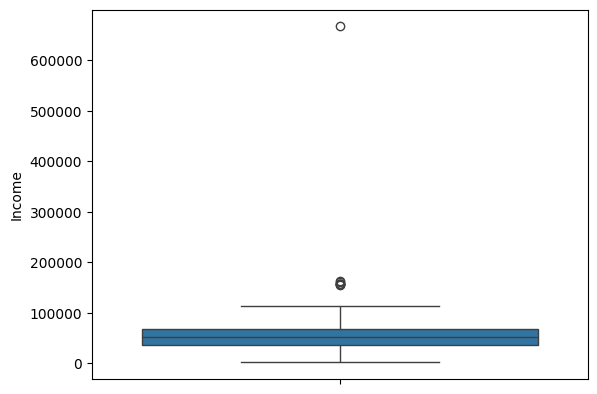

In [276]:
sns.boxplot(df['Income'])

In [277]:
# Imputing missing values with median
df['Income'].fillna(df['Income'].median(), inplace=True)

In [278]:
df['Income'].isnull().sum()

np.int64(0)

In [279]:
df.describe()
# Average Recency ≈ 49 days
#  implies that the Customers spend the most on wine products

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


In [280]:
df['Z_CostContact'].unique()

array([3])

In [281]:
df['Z_Revenue'].unique()

array([11])

In [282]:
df.drop(columns = ['Z_CostContact','Z_Revenue'],inplace=True)

In [283]:
df.duplicated().sum()

np.int64(0)

**Age**

In [284]:
# creating new feature age
df['Age'] = 2026 - df['Year_Birth']

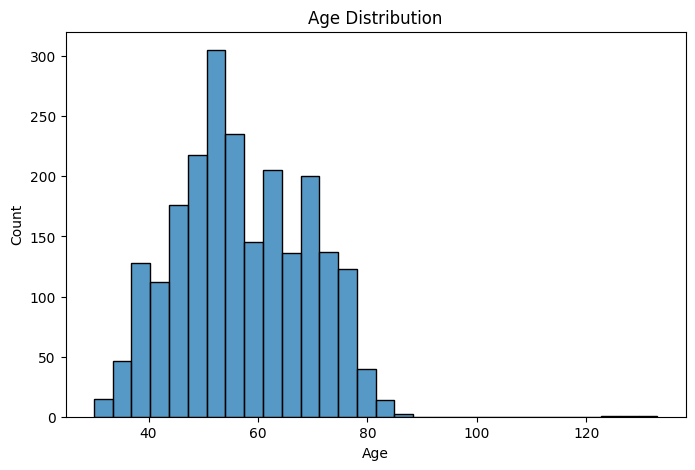

In [285]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

# Most customers are between 40–65 years
# This means the company mainly targets middle-aged customers.

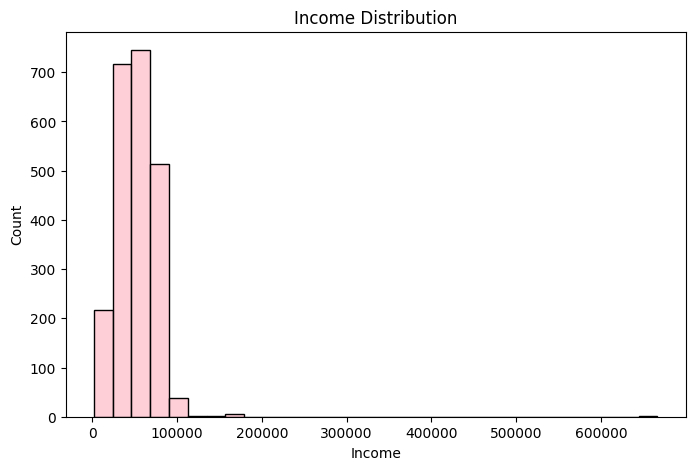

In [286]:
# income distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30 , color='pink')
plt.title("Income Distribution")
plt.show()

Income is right-skewed

Some customers have very high income

Indicates presence of outliers

In [287]:

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]

In [288]:
# Education Analysis
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [289]:
df['Education'] = df['Education'].replace({
    'Graduation':'Bachelor',
    '2n Cycle':'Master'
})
df['Education'].unique()

array(['Bachelor', 'PhD', 'Master', 'Basic'], dtype=object)

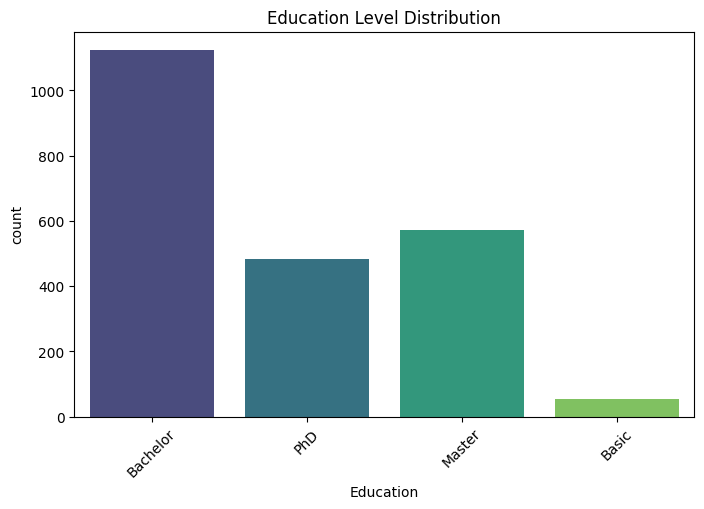

In [290]:
plt.figure(figsize=(8,5))
sns.countplot(x='Education', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title("Education Level Distribution")
plt.show()

Most common education levels:

Graduation

Master

PhD

This suggests highly educated customers dominate the dataset.

In [291]:
# Marital status Analysis
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [292]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Absurd':'Single',
    'Alone':'Single',
    'YOLO':'Single',
    'Together':'Relationship'
})
df['Marital_Status'].unique()

array(['Single', 'Relationship', 'Married', 'Divorced', 'Widow'],
      dtype=object)

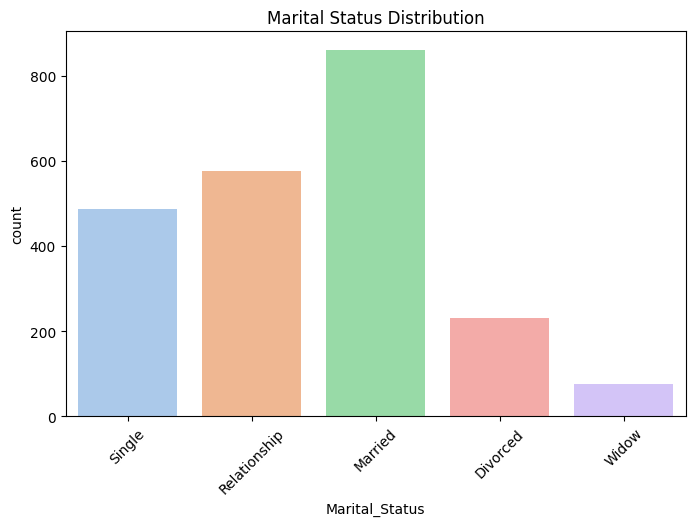

In [293]:
plt.figure(figsize=(8,5))
sns.countplot(x='Marital_Status', data=df , palette='pastel')
plt.xticks(rotation=45)
plt.title("Marital Status Distribution")
plt.show()

**Total Children**

In [294]:
# creating a new feature to calculate total number of children present in house-hold
df['Children'] = df['Kidhome'] + df['Teenhome']

Helps understand family size influence on spending.

Customers with more children may spend differently.

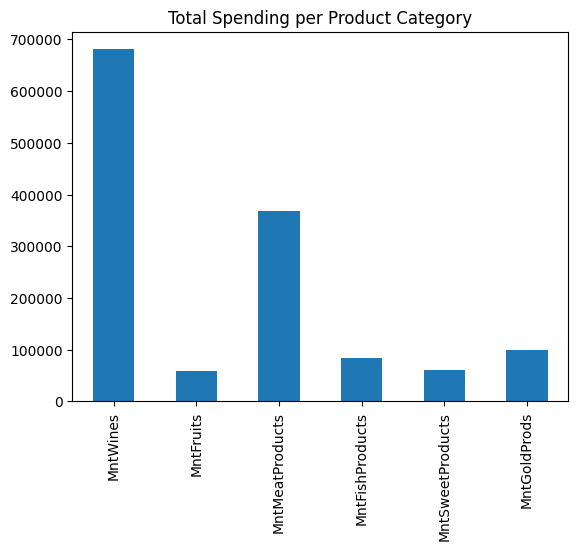

In [295]:
# Product Spending Analysis
products = ['MntWines','MntFruits','MntMeatProducts',
            'MntFishProducts','MntSweetProducts','MntGoldProds']

df[products].sum().plot(kind='bar')

plt.title("Total Spending per Product Category")
plt.show()

Highest spending:Wine,Meat products
Lowest spending:Fruits,Sweets
Meaning:Customers prefer premium products.

**Total Spending**

In [296]:
# creating a new feature called total spending
df['Total_Spending'] = df[products].sum(axis=1)
#Combines all product spending into one useful feature for segmentation.

Shows how much each customer spent in total.

Useful to identify high-value customers.

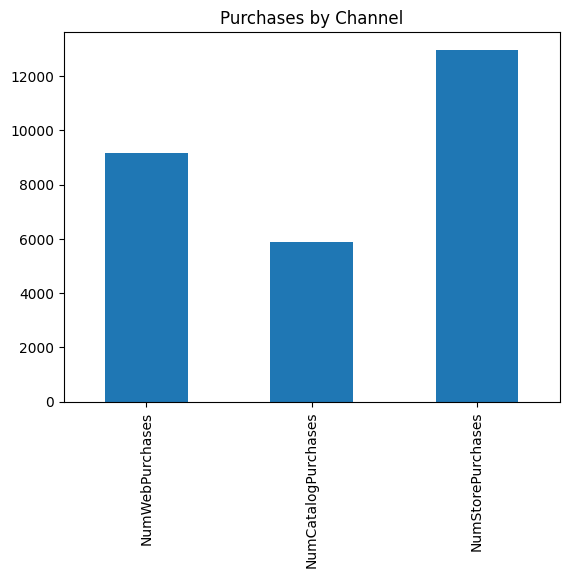

In [297]:
# Purchase Channel Analysis
channels = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']

df[channels].sum().plot(kind='bar')

plt.title("Purchases by Channel")
plt.show()

Most purchases occur in:

1️ Store

2️ Web

3️ Catalog

This suggests physical stores are still the dominant channel.

**Total Purchases**

In [298]:
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

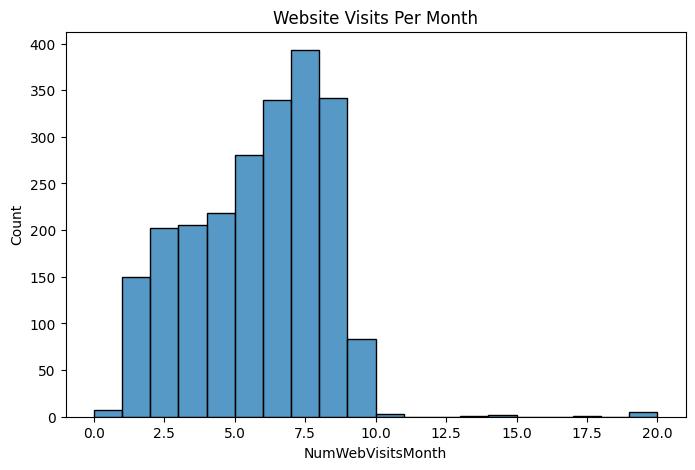

In [299]:
# Website Behavior

plt.figure(figsize=(8,5))
sns.histplot(df['NumWebVisitsMonth'], bins=20)
plt.title("Website Visits Per Month")
plt.show()

Customers visit the website frequently but do not always purchase, indicating potential for targeted online promotions.

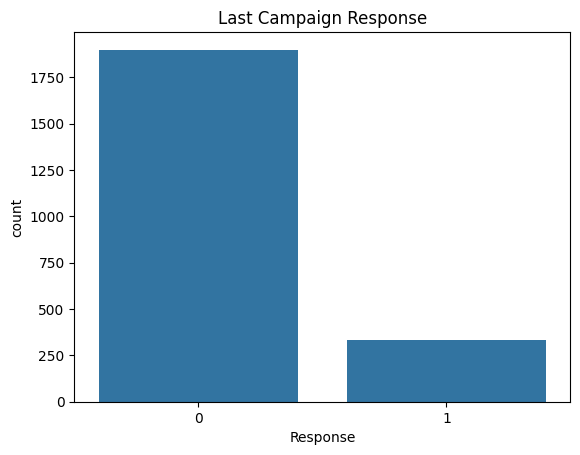

In [300]:
# Campaign Response Analysis
sns.countplot(x='Response', data=df)
plt.title("Last Campaign Response")
plt.show()

Most customers did not respond to the last campaign.

Approximate acceptance rate:
~15%

Meaning:
Marketing campaigns are not very effective.

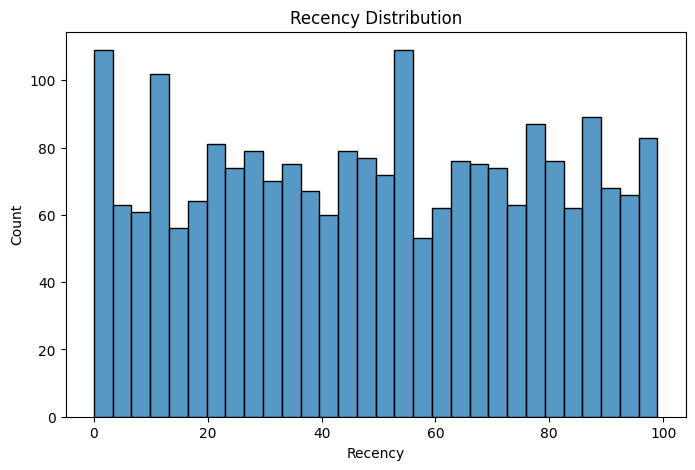

In [301]:
plt.figure(figsize=(8,5))
sns.histplot(df['Recency'], bins=30)
plt.title("Recency Distribution")
plt.show()

#Recency measures days since last purchase.Lower recency = more active customers.

**Customer Seniority**

In [302]:
df['Customer_Years'] = 2026 - df['Dt_Customer'].dt.year

Shows how long a customer has been with the company.

Insight

Long-term customers may have higher loyalty.

Useful for customer lifetime value analysis.

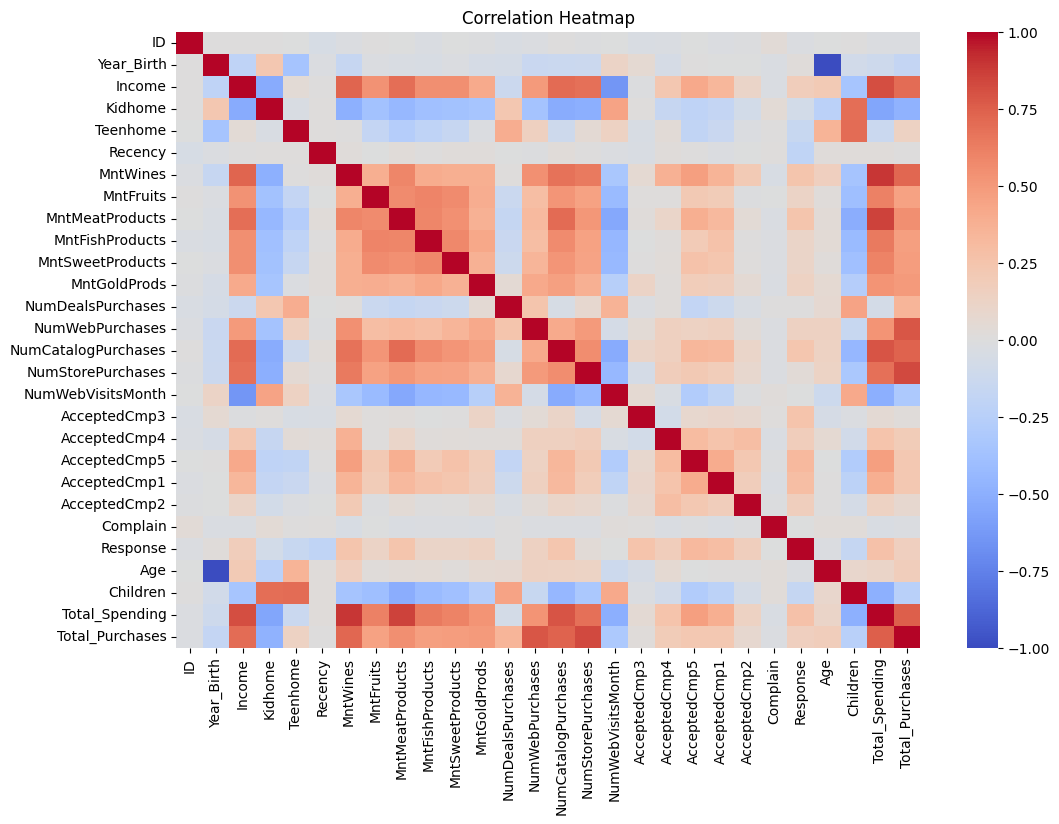

In [303]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [304]:
# This creates a column showing the campaign number accepted.
def get_campaign(row):
    for i in range(1,6):
        if row[f'AcceptedCmp{i}'] == 1:
            return i
    return 0   # if no campaign accepted

df['Accepted_Campaign'] = df.apply(get_campaign, axis=1)

A new feature Accepted_Campaign was created to identify which marketing campaign a customer responded to. This helps analyze the effectiveness of individual campaigns and understand customer response patterns.

In [305]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Children,Total_Spending,Total_Purchases,Customer_Years,Accepted_Campaign
0,5524,1957,Bachelor,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,1,69,0,1617,25,14,0
1,2174,1954,Bachelor,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,72,2,27,6,12,0
2,4141,1965,Bachelor,Relationship,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,61,0,776,21,13,0
3,6182,1984,Bachelor,Relationship,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,42,1,53,8,12,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,45,1,422,19,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Bachelor,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,59,1,1341,18,13,0
2236,4001,1946,PhD,Relationship,64014.0,2,1,2014-06-10,56,406,...,1,0,0,0,80,3,444,22,12,1
2237,7270,1981,Bachelor,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,0,0,45,0,1241,19,12,4
2238,8235,1956,Master,Relationship,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,70,1,843,23,12,0


In [306]:
features =['Income', 'Recency', 'Age', 'Children',
       'Total_Spending', 'Total_Purchases']
x = df[features]

In [307]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

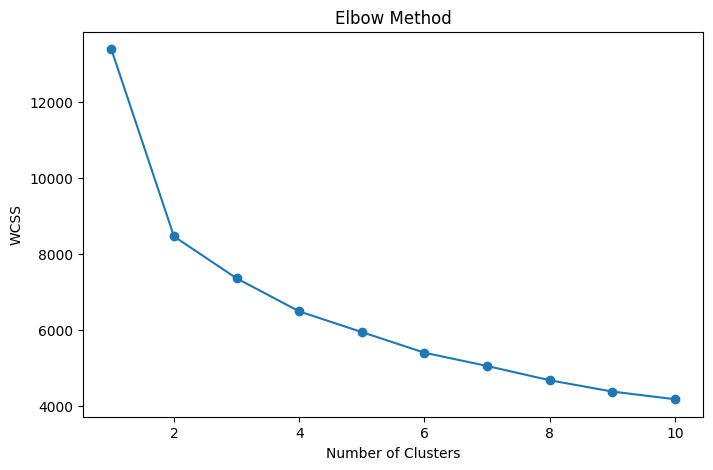

In [308]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [309]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.32618365170531655
K=3, Score=0.24245843891898153
K=4, Score=0.21322706499274227
K=5, Score=0.21482688517355253
K=6, Score=0.20377349373474593
K=7, Score=0.20042782844471063
K=8, Score=0.21060547708969288
K=9, Score=0.2143940444482349


In [310]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [311]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.24245843891898153


In [312]:
cluster_summary = df.groupby('Cluster')[features].mean(numeric_only=True)
print(cluster_summary)


               Income    Recency        Age  Children  Total_Spending  \
Cluster                                                                 
0        70962.955044  49.245614  59.049342  0.494518     1221.197368   
1        46223.202044  50.610063  63.347484  1.724843      245.539308   
2        30883.125000  47.538012  49.042398  0.842105      119.584795   

         Total_Purchases  
Cluster                   
0              21.671053  
1              12.306604  
2               8.153509  


Cluster 0: High-Value Customers

*  High income with very high spending
*  Frequent purchases (high engagement)
*  Contribute most to business revenue

Cluster 1: Moderate / Family Customers  
*  Moderate income and moderate spending
*  Higher number of children (family-oriented)
*  Purchase occasionally with budget considerations

Cluster 2: Low-Value Customers

*  Low income and low spending
* Less frequent purchases
* Limited contribution to overall revenue

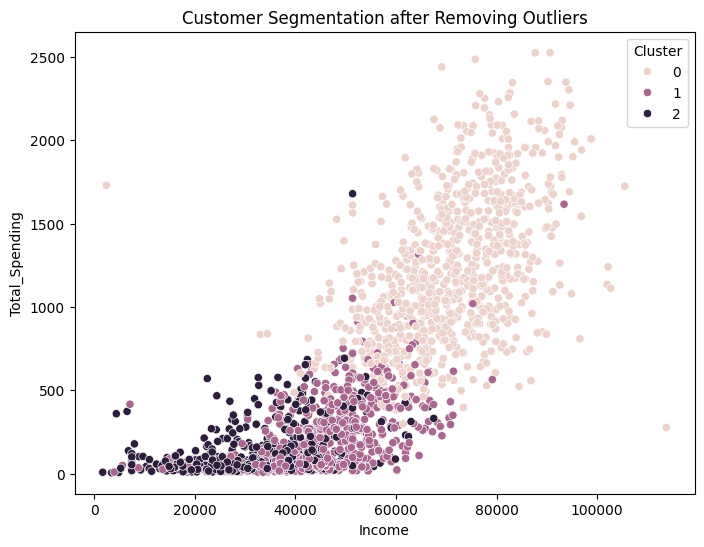

In [313]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Income'],
                y=df['Total_Spending'],
                hue=df['Cluster'])

plt.title("Customer Segmentation after Removing Outliers")
plt.show()

Deployment

In [315]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [316]:
from google.colab import files

files.download("kmeans_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>